In [20]:
%%capture
!pip install -U bitsandbytes

In [72]:
from PIL import Image
from io import BytesIO
from IPython.display import display
import torch, torch.nn as nn, requests, math
from peft import prepare_model_for_kbit_training, get_peft_model, TaskType, LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoModel, AutoProcessor, BitsAndBytesConfig

In [8]:
class Config:
    device = "cuda"
    qformer_weight = "/kaggle/input/models/edifonjimmy/qformer/pytorch/default/1/checkpoints/qformer_best.pt"
    vision_processor_name = "google/siglip-so400m-patch14-384"
    llm_model_name = "Qwen/Qwen3-0.6B"
    embedding_dim = 1024
    vision_dim_model = 1152
    max_length=1024
    layer_bias = True
    n_heads = 16
    truncation = True
    padding = True
    dropout = 0
    n_queries = 32
    n_layers = 12

In [6]:
weight_dict = torch.load(Config.qformer_weight, map_location=Config.device)

In [11]:
class QFormerAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        assert config.embedding_dim % config.n_heads == 0, f"n_heads={config.n_heads} must divide embedding_dim={config.embedding_dim}"
        self.d_k = config.embedding_dim // config.n_heads

        self.q_proj      = nn.Linear(config.embedding_dim, config.embedding_dim, bias=config.layer_bias)
        self.k_proj      = nn.Linear(config.embedding_dim, config.embedding_dim, bias=config.layer_bias)
        self.v_proj      = nn.Linear(config.embedding_dim, config.embedding_dim, bias=config.layer_bias)
        self.output_proj = nn.Linear(config.embedding_dim, config.embedding_dim, bias=config.layer_bias)

    def split_heads(self, x):
        B, N, _ = x.shape
        return x.view(B, N, self.config.n_heads, self.d_k).transpose(1, 2)

    def forward(self, query, key_value):
        """
        query     : (B, n_queries, embedding_dim)
        key_value : (B, T_kv,     embedding_dim)
                    — same tensor as query for self-attention
                    — image patch features for cross-attention
        N -> sequence length
        """
        B, N, _ = query.shape

        q = self.split_heads(self.q_proj(query))      # (B, H, N, d_k)
        k = self.split_heads(self.k_proj(key_value))  # (B, H, T_kv, d_k)
        v = self.split_heads(self.v_proj(key_value))  # (B, H, T_kv, d_k)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B, H, N, T_kv)
        att = torch.softmax(att, dim=-1)

        out = att @ v                                           # (B, H, N, d_k)
        out = out.transpose(1, 2).contiguous().view(B, N, -1)  # (B, N, embedding_dim)
        return self.output_proj(out)


class QFormerLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention  = QFormerAttention(config)
        self.cross_attention = QFormerAttention(config)

        self.norm1 = nn.LayerNorm(config.embedding_dim)
        self.norm2 = nn.LayerNorm(config.embedding_dim)
        self.norm3 = nn.LayerNorm(config.embedding_dim)

        self.ffn = nn.Sequential(
            nn.Linear(config.embedding_dim, 4 * config.embedding_dim),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(4 * config.embedding_dim, config.embedding_dim),
            nn.Dropout(config.dropout),
        )

    def forward(self, queries, image_feat):
        # Self-attention: queries attend to themselves
        queries = queries + self.self_attention(self.norm1(queries), self.norm1(queries))

        # Cross-attention: queries attend to image patches
        queries = queries + self.cross_attention(self.norm2(queries), image_feat)
        
        # Feed-forward
        queries = queries + self.ffn(self.norm3(queries))

        return queries


class QFormer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        self.img_to_llm_proj = nn.Linear(config.vision_dim_model, config.embedding_dim, bias=config.layer_bias)

        self.query_tokens = nn.Parameter(torch.zeros(1, config.n_queries, config.embedding_dim))
        nn.init.trunc_normal_(self.query_tokens, std=0.02)

        self.layers = nn.ModuleList([QFormerLayer(config) for _ in range(config.n_layers)])
        self.norm   = nn.LayerNorm(config.embedding_dim)

    def forward(self, image_features):
        """
        image_features: (B, n_patches, vision_dim_model)
        returns:        (B, n_queries, embedding_dim)
        """
        B = image_features.size(0)

        # Project once
        img = self.img_to_llm_proj(image_features)  # (B, n_patches, embedding_dim)

        queries = self.query_tokens.expand(B, -1, -1)  # (B, n_queries, embedding_dim)

        for layer in self.layers:
            queries = layer(queries, img)

        return self.norm(queries)


qformer = QFormer(Config)

qformer.load_state_dict(weight_dict["qformer_state_dict"])

<All keys matched successfully>

In [26]:
model = AutoModelForCausalLM.from_pretrained(Config.llm_model_name,
                                             torch_dtype=torch.bfloat16,
                                             device_map="auto",
                                             quantization_config=BitsAndBytesConfig(
                                                 load_in_4bit=True,
                                                 bnb_4bit_quant_type="nf4",
                                                 bnb_4bit_compute_dtype=torch.bfloat16,
                                                 bnb_4bit_use_double_quant=True,
                                             ))

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=4,
    lora_alpha=4,
    lora_dropout=0.0,
    bias="none",
    target_modules="all-linear",
)

model = get_peft_model(model, lora_config)

text_tokenizer = AutoTokenizer.from_pretrained(Config.llm_model_name)
text_tokenizer.pad_token = text_tokenizer.eos_token

vision_model = AutoModel.from_pretrained(Config.vision_processor_name).to(model.device)
vision_processor = AutoProcessor.from_pretrained(Config.vision_processor_name)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [27]:
text_tokenizer.chat_template = """{%- for message in messages %}
    {%- if message.role == "system" %}
        {{- '<|im_start|>system\n' + message.content + '<|im_end|>\n' }}
    {%- elif message.role == "user" %}
        {{- '<|im_start|>user\n' + message.content + '<|im_end|>\n' }}
    {%- elif message.role == "assistant" %}
        {{- '<|im_start|>assistant\n' + message.content + '<|im_end|>\n' }}
    {%- endif %}
{%- endfor %}
{%- if add_generation_prompt %}
    {{- '<|im_start|>assistant\n<think>\n\n</think>\n' }}
{%- endif %}"""

In [28]:
class BlipProcessor(nn.Module):
    def __init__(self, config, image_processor, text_processor):
        super().__init__()
        self.config = config
        self.text_processor = text_processor
        self.image_processor = image_processor

    def preprocess_image(self, image):
        return self.image_processor(image, return_tensors="pt")["pixel_values"].to(self.config.device)

    def preprocess_text(self, text):
        prep_text = self.text_processor(text, 
                                        return_tensors="pt",
                                        padding=self.config.padding, 
                                        truncation=self.config.truncation, 
                                        max_length=self.config.max_length).to(self.config.device)
        input_ids = prep_text["input_ids"]
        attention_mask = prep_text["attention_mask"]
        return input_ids, attention_mask
        
    def forward(self, image, text):
        image = self.preprocess_image(image)
        input_ids, attention_mask = self.preprocess_text(text)
        return image, input_ids, attention_mask


blip_processor = BlipProcessor(Config, vision_processor, text_tokenizer)

In [29]:
class BLIP2Model(nn.Module):
    def __init__(self, config, text_model, image_model, qformer, blip_processor):
        super().__init__()
        self.config          = config
        self.image_model     = image_model
        self.text_model      = text_model
        self.qformer         = qformer
        self.blip_processor  = blip_processor

        for param in self.image_model.parameters():
            param.requires_grad = False
        for param in self.text_model.parameters():
            param.requires_grad = False

    def create_label(self, txt_input_ids, label_indicator="<|im_start|>assistant"):
        indicator_ids = self.blip_processor.text_processor.encode(label_indicator, add_special_tokens=False)
        input_ids = txt_input_ids.clone()
        input_ids[input_ids == self.blip_processor.text_processor.pad_token_id] = -100
    
        for i in range(input_ids.shape[0]):
            ids = input_ids[i].tolist()
            for j in range(len(ids) - len(indicator_ids) + 1):
                if ids[j:j + len(indicator_ids)] == indicator_ids:
                    input_ids[i, :j + len(indicator_ids)] = -100
                    break
                    
        return input_ids

    def forward(self, image, text, inference=False):
        # Preprocessing 
        pixel_values, input_ids, attn_mask = self.blip_processor(image, text)

        # Frozen ViT 
        with torch.no_grad():
            image_features = self.image_model.vision_model(pixel_values).last_hidden_state[:, 1:, :]

        # Q-Former
        query_output  = self.qformer(image_features) # (B, n_queries, embedding_dim)

        # Prepend visual tokens to text embeddings
        text_embeds    = self.text_model.get_input_embeddings()(input_ids)
        inputs_embeds  = torch.cat([query_output, text_embeds], dim=1)

        # Extend attention mask
        visual_attn_mask = torch.ones((pixel_values.shape[0],
                                       query_output.shape[1]),
                                      dtype=attn_mask.dtype,
                                      device=pixel_values.device)
        
        full_attn_mask = torch.cat([visual_attn_mask, attn_mask], dim=1)
    
        # Labels
        labels = None
        if not inference:
            raw_labels = self.create_label(input_ids)
            
            visual_label_mask = torch.full((pixel_values.size(0), query_output.size(1)), 
                                           fill_value=-100,
                                           dtype=raw_labels.dtype, 
                                           device=pixel_values.device)
            
            labels = torch.cat([visual_label_mask, raw_labels], dim=1)

        return self.text_model(
                inputs_embeds=inputs_embeds,
                attention_mask=full_attn_mask,
                labels=labels,
            )


blip_model = BLIP2Model(Config,
                        model,
                        vision_model, 
                        qformer, 
                        blip_processor).to(Config.device)

In [34]:
def InferenceMode(trainer, image, text_prompt, config):
    model = trainer.blip_model if hasattr(trainer, "blip_model") else trainer
    
    model.eval()
    with torch.no_grad():
        pixel_values, input_ids, attn_mask = blip_processor(image, text_prompt)  
        image_features = model.image_model.vision_model(pixel_values).last_hidden_state[:, 1:, :]
        
        query_output  = model.qformer(image_features) 
        text_embeds    = model.text_model.get_input_embeddings()(input_ids)
        
        inputs_embeds  = torch.cat([query_output, text_embeds], dim=1)

        # Extend attention mask
        visual_attn_mask = torch.ones((pixel_values.shape[0],
                                       query_output.shape[1]),
                                       dtype=attn_mask.dtype,
                                       device=config.device)
        
        full_attn_mask = torch.cat([visual_attn_mask, attn_mask], dim=1)
        
        generated_ids = model.text_model.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=full_attn_mask,
            max_new_tokens=256,        
            do_sample=False,
            repetition_penalty=1.2,
            pad_token_id=blip_processor.text_processor.pad_token_id,
            eos_token_id=blip_processor.text_processor.eos_token_id,
        )
    decoded = blip_processor.text_processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )
    return decoded[0]

In [56]:
def GetImage(url: str):
    response = requests.get(url, timeout=10)

    if response.status_code == 200:
        return Image.open(BytesIO(response.content)).convert("RGB")

    raise Exception("Can't get image")

In [123]:
image_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQnBoXfvQDWDsFAEoKp6vSyxSm4VRZv5uTl5Q&s"

In [128]:
image = GetImage(image_url)

In [125]:
prompt = [
    {"role":"system", "content":"You are an expert image captioning assistant."},
    {"role": "user",  "content": "Write a natural, single-sentence caption describing the image."}
]

In [126]:
chat_temp = text_tokenizer.apply_chat_template(
            prompt,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False
)

print(chat_temp)

<|im_start|>system
You are an expert image captioning assistant.<|im_end|>
<|im_start|>user
Write a natural, single-sentence caption describing the image.<|im_end|>
<|im_start|>assistant
<think>

</think>



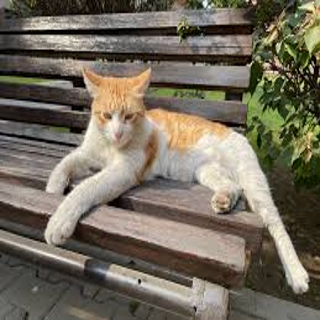

Caption: A cat is sitting on a bench.


In [130]:
display(image.resize((320, 320)))

print("Caption:", InferenceMode(blip_model, image, chat_temp, Config))